In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [2]:
plt.style.use('ggplot')

In [3]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")
data_dpt = pd.read_csv("csvs/departamento.csv")

In [4]:
padrao_avaliadores = r'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [5]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}

In [6]:
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

## Triângulos

In [7]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_undirected = nx.Graph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_undirected.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [8]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_undirected.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_undirected[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_undirected.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [9]:
triangles = nx.triangles(grafo_defesas_single_undirected)

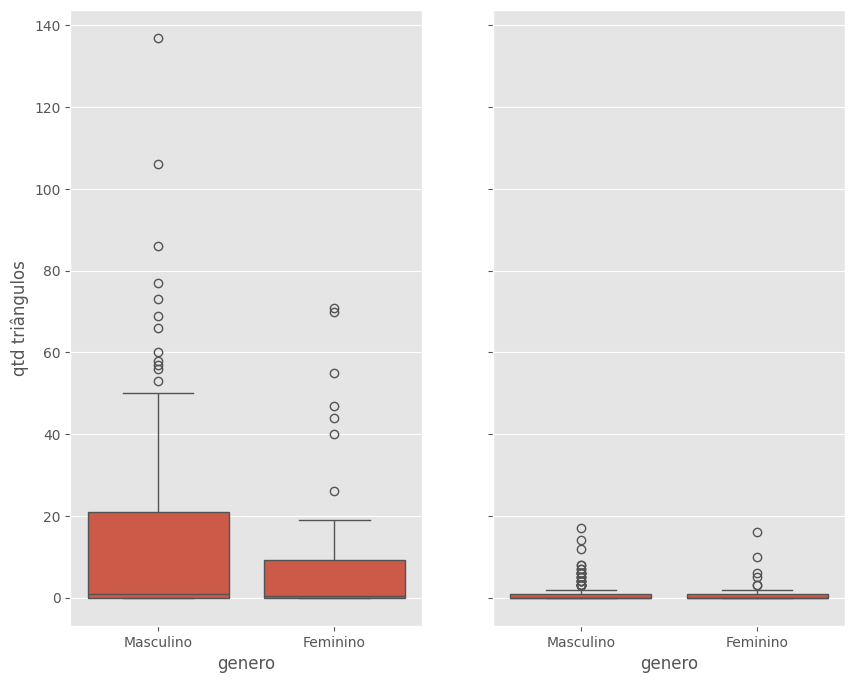

In [11]:
df_tri = collections.defaultdict(list)
for person, qtd in triangles.items():
    info = grafo_defesas_single_undirected.nodes[person]
    df_tri["genero"].append(info["genero"])
    df_tri["qtd triângulos"].append(qtd)
    df_tri["filiacao_genero"].append(info["filiacao_genero"])
df_tri = pd.DataFrame(df_tri)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("interno")], x="genero", y="qtd triângulos",
            ax=ax[0])
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("externo")], x="genero", y="qtd triângulos",
            ax=ax[1])
plt.show()

## Clusterização

In [7]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_directed = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_directed.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [8]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_directed.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_directed[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_directed.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [125]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas_single_directed.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas_single_directed.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas_single_directed.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas_single_directed.out_degree() if degree == max_degree_out]

max_degree = 0
for no, degree in grafo_defesas_single_directed.degree():
    if degree > max_degree:
        max_degree = degree
max_degree_person = [no for no, degree in grafo_defesas_single_directed.degree() if degree == max_degree]

In [127]:
print(f"Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)")
for person in max_degree_person_out:
    print(grafo_defesas_single_directed.nodes[person], f"Qtd de orientações: {grafo_defesas_single_directed.out_degree[person]}")

Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)
{'nome': 'Ricardo Torres', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino', 'filiacao_genero': 'Masculino_interno', 'bipartite': 0, 'marker': 'M', 'cor_bin': 'red', 'cor': 'aliceblue'} Qtd de orientações: 67


In [24]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight")
np.mean([v for v in clustering.values()]), np.std([v for v in clustering.values()])

(np.float64(0.013196559310536602), np.float64(0.025953859666112928))

In [22]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight",
                          nodes=[node for node in grafo_defesas_single_directed.nodes() if grafo_defesas_single_directed.nodes[node]["genero"]=="Feminino"])
np.mean([v for v in clustering.values()]), np.std([v for v in clustering.values()])

(np.float64(0.014072020018893053), np.float64(0.02635574785360571))

In [23]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight",
                          nodes=[node for node in grafo_defesas_single_directed.nodes() if grafo_defesas_single_directed.nodes[node]["genero"]=="Masculino"])
np.mean([v for v in clustering.values()]), np.std([v for v in clustering.values()])

(np.float64(0.012979501763062671), np.float64(0.025856953412182766))

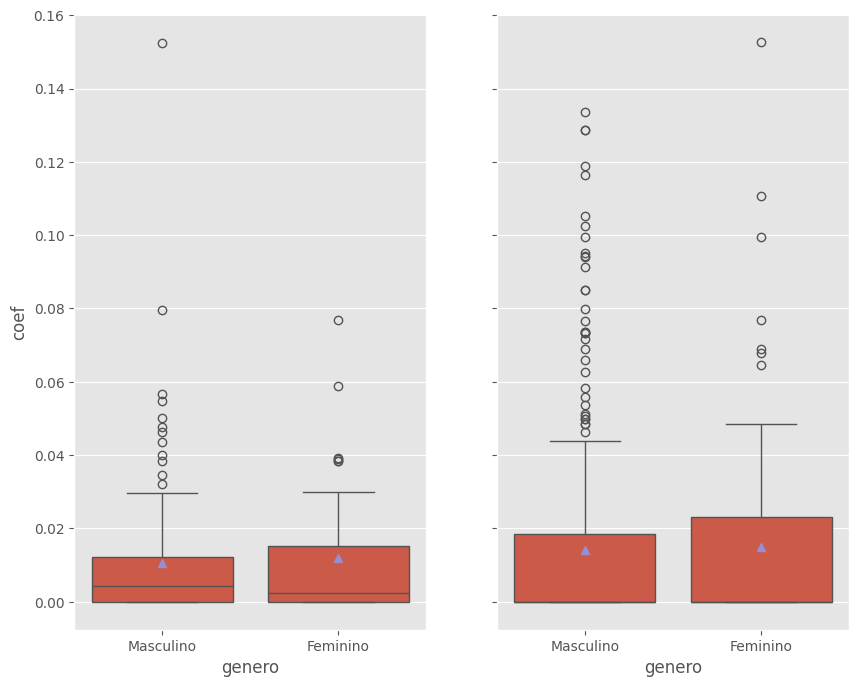

In [25]:
df_clustering = collections.defaultdict(list)
for person, coef in clustering.items():
    info = grafo_defesas_single_directed.nodes[person]
    df_clustering["genero"].append(info["genero"])
    df_clustering["coef"].append(coef)
    df_clustering["filiacao_genero"].append(info["filiacao_genero"])
df_clustering = pd.DataFrame(df_clustering)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("interno")],
            x="genero", y="coef", showmeans=True,
            ax=ax[0])
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("externo")],
            x="genero", y="coef", showmeans=True,
            ax=ax[1])
plt.show()

## Comunidade

In [22]:
G = nx.barbell_graph(5, 1)
communities_generator = nx.community.girvan_newman(G)
top_level_communities = next(communities_generator)
next_level_communities = next(communities_generator)
sorted(map(sorted, next_level_communities))

[[0, 1, 2, 3, 4], [5], [6, 7, 8, 9, 10]]

In [23]:
sorted(map(sorted, top_level_communities))

[[0, 1, 2, 3, 4], [5, 6, 7, 8, 9, 10]]

In [31]:
coms = nx.community.girvan_newman(grafo_defesas_single_directed)

In [34]:
import itertools

In [39]:
len(communities)

24

In [41]:
len(communities)

15

In [42]:
nx.community.modularity(grafo_defesas_single_directed, communities)

0.023436088026630046

In [45]:
k=20
coms = nx.community.girvan_newman(grafo_defesas_single_directed)
for i, communities in enumerate(itertools.islice(coms, k)):
    # print(tuple(sorted(c) for c in communities))
    # break
    print(len(communities), i, nx.community.modularity(grafo_defesas_single_directed, communities))

15 0 0.023436088026630046
16 1 0.2636218659641604
17 2 0.4754187245536727
18 3 0.4967616005678289
19 4 0.5013213700996507
20 5 0.5121782169958907
21 6 0.5181954748097948
22 7 0.494734362270517
23 8 0.4992552047826646
24 9 0.5015036193281247
25 10 0.5116337442661637
26 11 0.5259988256173156
27 12 0.5255835198165072
28 13 0.5121622923060241
29 14 0.5012255691875956
30 15 0.48849365325276956
31 16 0.4870217569179507
32 17 0.4601320333730945
33 18 0.45190528803340446
34 19 0.4518893633435378


In [45]:
for c_ in c:
    print(len(c_))

479
1
1
1
1
1
1
15
3
1
1
1
4
3
1


## Componente fortemente conectada

In [56]:
data_dpt[data_dpt["orcid"]==url.split("/")[-1]]

,orcid,nome,departamento


In [65]:
data_dpt[data_dpt["orcid"]==url.split("/")[-1]]

,orcid,nome,departamento


In [66]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        if data_dpt[data_dpt["orcid"]==url].shape[0] == 0:
            dpt = None
        else:
            # print(data.at[index, f"{col}_nome"])
            dpt = data_dpt[data_dpt["orcid"]==url]["departamento"].values[0]
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]],
                            dpt=dpt
                            )
    n_banca -=- 1

In [67]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval][0]["weight"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [57]:
sccs = nx.strongly_connected_components(grafo_defesas)
largest = max(sccs, key=len)

In [58]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="twopi")

In [67]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1
for ano in range(2006, 2025):
    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        pesos_arestas[(person1, person2)]-=-.1
        edge_ano.append((person1, person2))
        pesos[person1]-=-10
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]
    # subgraph_ano = grafo_defesas.edge_subgraph(edges_ano)
    # sccs_ano = nx.strongly_connected_components(subgraph_ano)
    # largest = max(sccs_ano, key=len)
    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(20,20))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    #### SCC
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=set([node for node, gender in set(nos_w_edge_ano)]).intersection(largest),
                           node_color="gold", node_size=200,node_shape="*")
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_scc_{ano}_pydot.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

## N e L do grafo

In [68]:
print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas.nodes)}")

Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): 514


In [69]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Feminino'])}")

Quantidade de nós F: 114


In [70]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Masculino'])}")

Quantidade de nós F: 399


In [71]:
print(f"Quantidade de links (cada link representa uma colaboração entre professores em uma banca): {len(grafo_defesas.edges)}")

Quantidade de links (cada link representa uma colaboração entre professores em uma banca): 1989


## Graus de entrada e saída por ano

In [12]:
df_dict = collections.defaultdict(list)
for ano in range(2006, 2025):
    edges_ano = []
    for person1, person2, infos in grafo_defesas.edges(data=True):
        # node1 = grafo_defesas.nodes[person1]
        # node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        edges_ano.append((person1, person2, 0))
    grafo_defesas_ano = grafo_defesas.edge_subgraph(edges_ano)
    # print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas_ano.nodes)}")
    k = np.array([d for _, d in grafo_defesas_ano.degree()]).mean()
    k_in = np.array([d for _, d in grafo_defesas_ano.in_degree()]).mean()
    k_out = np.array([d for _, d in grafo_defesas_ano.out_degree()]).mean()
    df_dict["k"].append(k)
    df_dict["k_in"].append(k_in)
    df_dict["k_out"].append(k_out)
    genero = "Feminino"
    grafo_defesas_genero = [x for x, y in grafo_defesas_ano.nodes(data=True) if y["genero"] == genero]
    graus = np.array([d for pessoa, d in grafo_defesas_ano.degree() if pessoa in grafo_defesas_genero])
    graus_saida = np.array([d for pessoa, d in grafo_defesas_ano.out_degree() if pessoa in grafo_defesas_genero])
    graus_entrada = np.array([d for pessoa, d in grafo_defesas_ano.in_degree() if pessoa in grafo_defesas_genero])
    df_dict["k_F"].append(graus.mean())
    df_dict["k_in_F"].append(graus_entrada.mean())
    df_dict["k_out_F"].append(graus_saida.mean())
    genero = "Masculino"
    grafo_defesas_genero = [x for x, y in grafo_defesas_ano.nodes(data=True) if y["genero"] == genero]
    graus = np.array([d for pessoa, d in grafo_defesas_ano.degree() if pessoa in grafo_defesas_genero])
    graus_saida = np.array([d for pessoa, d in grafo_defesas_ano.out_degree() if pessoa in grafo_defesas_genero])
    graus_entrada = np.array([d for pessoa, d in grafo_defesas_ano.in_degree() if pessoa in grafo_defesas_genero])
    df_dict["k_M"].append(graus.mean())
    df_dict["k_in_M"].append(graus_entrada.mean())
    df_dict["k_out_M"].append(graus_saida.mean())

In [150]:
df = pd.DataFrame(df_dict)

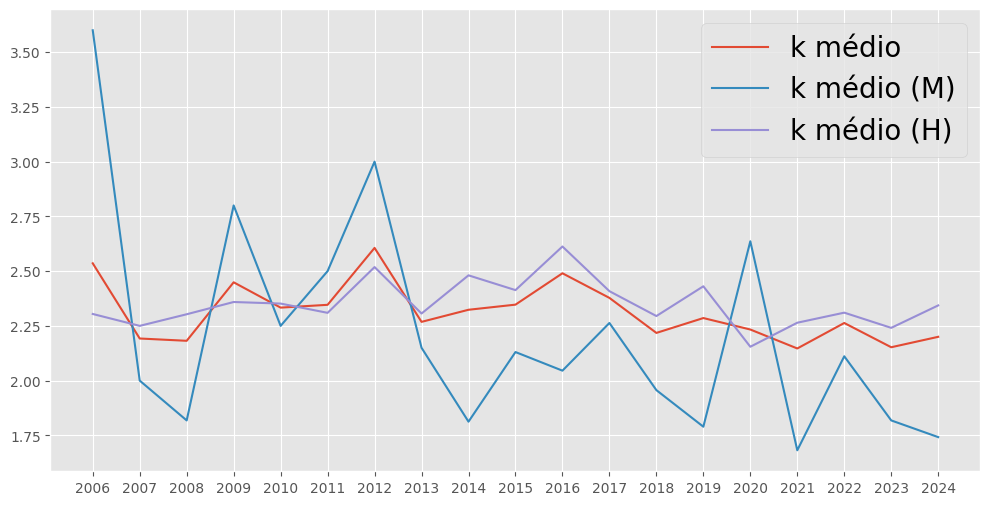

In [152]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k"], label="k médio")
ax.plot(range(2006, 2025), df_dict["k_F"], label="k médio (M)")
ax.plot(range(2006, 2025), df_dict["k_M"], label="k médio (H)")
ax.legend(fontsize=20)
_=ax.set_xticks(range(2006,2025))

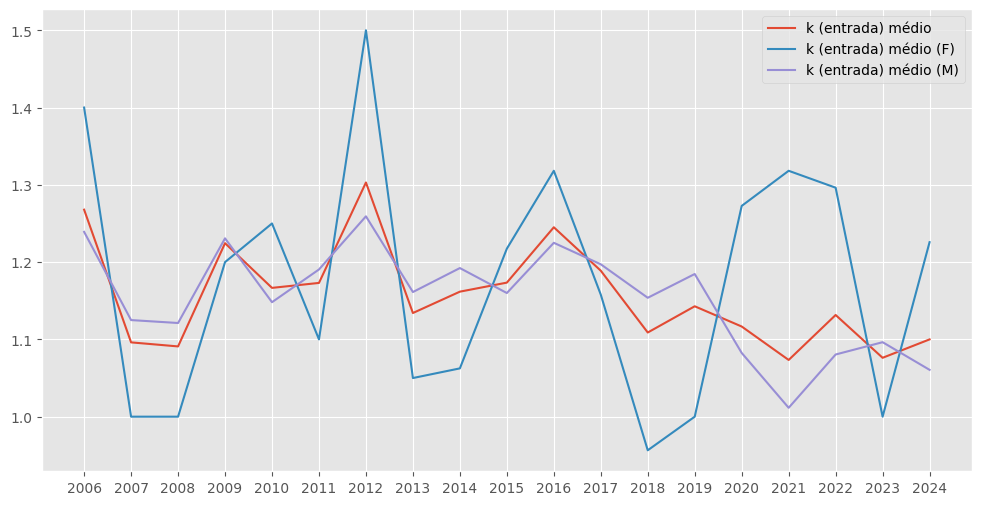

In [143]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k_in"], label="k (entrada) médio")
ax.plot(range(2006, 2025), df_dict["k_in_F"], label="k (entrada) médio (F)")
ax.plot(range(2006, 2025), df_dict["k_in_M"], label="k (entrada) médio (M)")
ax.legend()
_=ax.set_xticks(range(2006,2025))

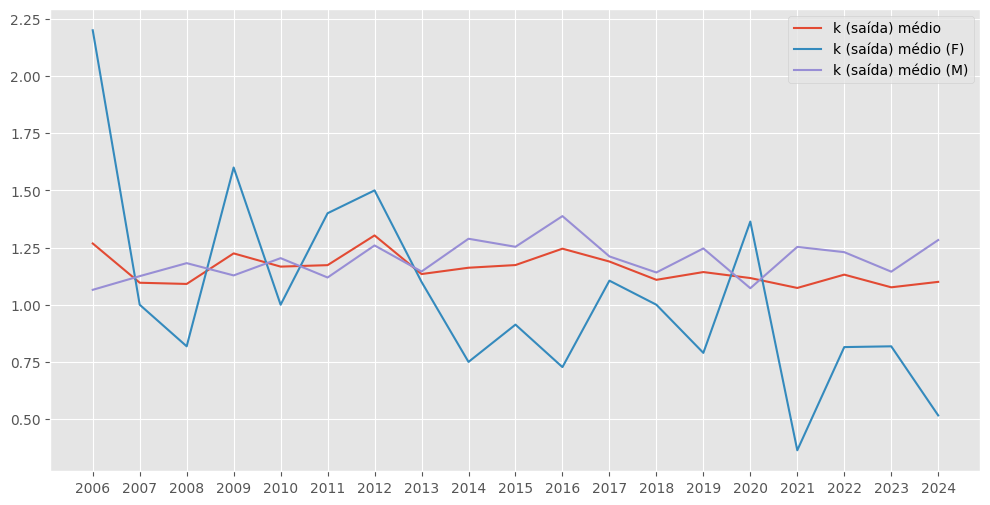

In [144]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k_out"], label="k (saída) médio")
ax.plot(range(2006, 2025), df_dict["k_out_F"], label="k (saída) médio (F)")
ax.plot(range(2006, 2025), df_dict["k_out_M"], label="k (saída) médio (M)")
ax.legend()
_=ax.set_xticks(range(2006,2025))

## IES que colaboraram +

In [69]:
node1

{'nome': 'Rodolfo Azevedo',
 'filiacao': 'Universidade Estadual de Campinas',
 'genero': 'Masculino',
 'filiacao_genero': 'Masculino_interno',
 'bipartite': 0,
 'marker': 'M',
 'cor_bin': 'red',
 'cor': 'aliceblue',
 'dpt': 'DSC'}

In [95]:
filiacao_alvo = "Universidade Estadual de Campinas"
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")
df_dict = collections.defaultdict(list)
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    df_dict["orient_filiacao_bin"].append("Unicamp" if node1['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["aval_filiacao_bin"].append("Unicamp" if node2['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["orient_genero"].append(node1["genero"])
    df_dict["aval_genero"].append(node2["genero"])
    df_dict["aval_filiacao"].append(node2["filiacao"])
    df_dict["ano_defesa"].append(infos["ano"])
    df_dict["tipo_defesa"].append(infos["tipo"])
    df_dict["pessoa orientadora"].append(node1["nome"])
    df_dict["pessoa avaliadora"].append(node2["nome"])
    df_dict["pessoa avaliadora filiacao"].append(node2["filiacao"])
    df_dict["pessoa orientadora departamento"].append(node1["dpt"])
    df_dict["pessoa avaliadora departamento"].append(node2["dpt"])
    df_dict["gêneros orientaçãoXavaliação"].append(f'{node1["genero"]}_{node2["genero"]}')
df = pd.DataFrame(df_dict)

<Axes: xlabel='count', ylabel='aval_filiacao'>

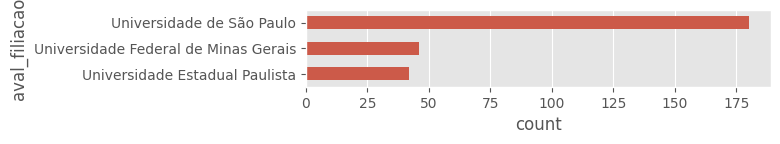

In [96]:
fig, ax = plt.subplots(figsize=(6,1.))
sns.countplot(data=df, y="aval_filiacao", order=df.aval_filiacao.value_counts().iloc[1:4].index, width=.5)

<Axes: xlabel='count', ylabel='pessoa orientadora'>

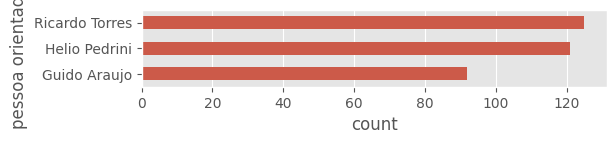

In [33]:
fig, ax = plt.subplots(figsize=(6,1.))
sns.countplot(data=df, y="pessoa orientadora", order=df["pessoa orientadora"].value_counts().iloc[0:3].index, width=.5)

<Axes: xlabel='count', ylabel='pessoa avaliadora'>

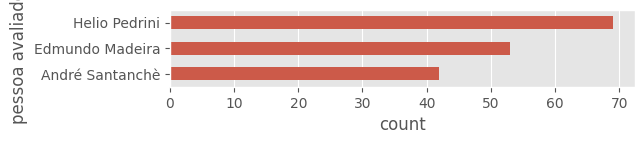

In [36]:
fig, ax = plt.subplots(figsize=(6,1))
sns.countplot(data=df, y="pessoa avaliadora", order=df["pessoa avaliadora"].value_counts().iloc[0:3].index, width=.5)

In [ ]:
fig, ax = plt.subplots(figsize=(6,1))
sns.countplot(data=df, y="genero", order=df["pessoa avaliadora"].value_counts().iloc[0:3].index, width=.5)

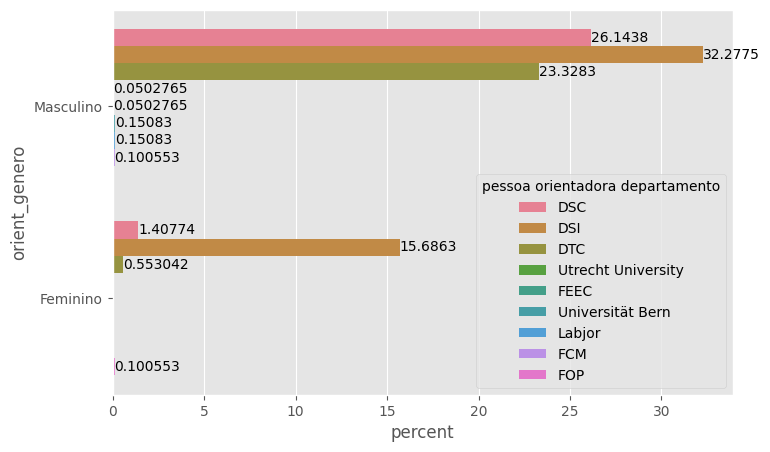

In [88]:
fig, ax = plt.subplots(figsize=(8,5))
c=sns.countplot(data=df, y="orient_genero", hue="pessoa orientadora departamento", stat="percent")
for i, _ in enumerate(df["pessoa orientadora departamento"].unique()):   
    c.bar_label(c.containers[i])

IndexError: list index out of range

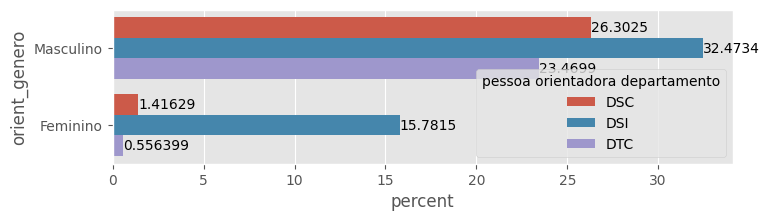

In [102]:
fig, ax = plt.subplots(figsize=(8,2))
c=sns.countplot(data=df[df["pessoa orientadora departamento"].isin(["DSC", "DSI","DTC"])],
                y="orient_genero", hue="pessoa orientadora departamento", stat="percent")
for i, _ in enumerate(df["pessoa orientadora departamento"].unique()):   
    c.bar_label(c.containers[i])

IndexError: list index out of range

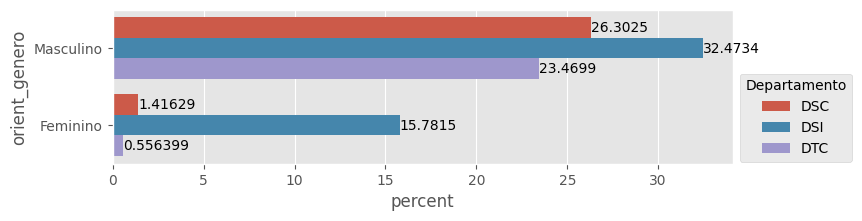

In [118]:
fig, ax = plt.subplots(figsize=(8,2))
c=sns.countplot(data=df[df["pessoa orientadora departamento"].isin(["DSC", "DSI","DTC"])],
                y="orient_genero", hue="pessoa orientadora departamento", stat="percent")
# ax.legend.set_title(new_title)
# ax.legend(legend_handles, ['man1','woman1','child1'], 
#           bbox_to_anchor=(1,1), 
#           title='whatever title you want to use')
plt.legend(title= "Departamento", loc= "upper left")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 0.63))
for i, _ in enumerate(df["pessoa orientadora departamento"].unique()):   
    c.bar_label(c.containers[i])

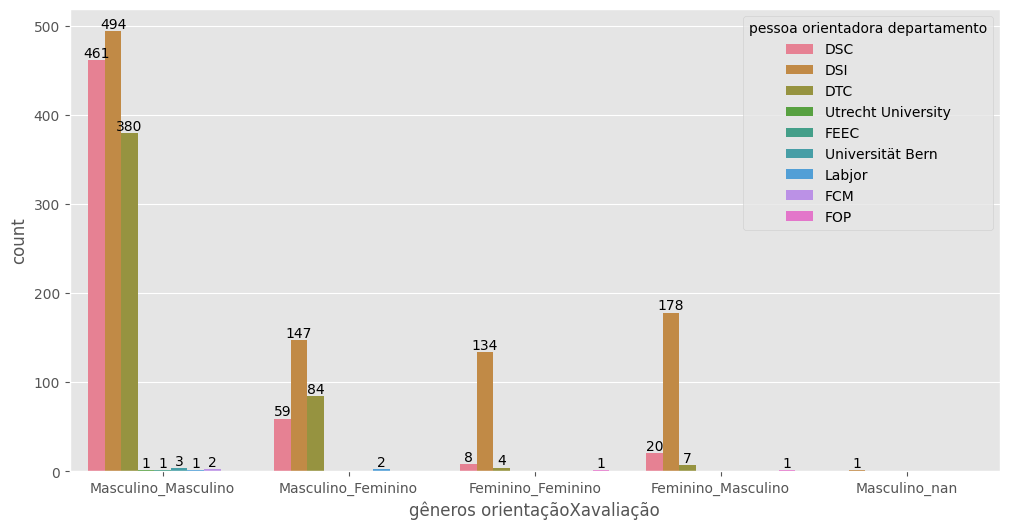

In [94]:
fig, ax = plt.subplots(figsize=(12,6))
c=sns.countplot(data=df, x="gêneros orientaçãoXavaliação", hue="pessoa orientadora departamento", stat="count")
for i, _ in enumerate(df["pessoa orientadora departamento"].unique()):   
    c.bar_label(c.containers[i])

IndexError: list index out of range

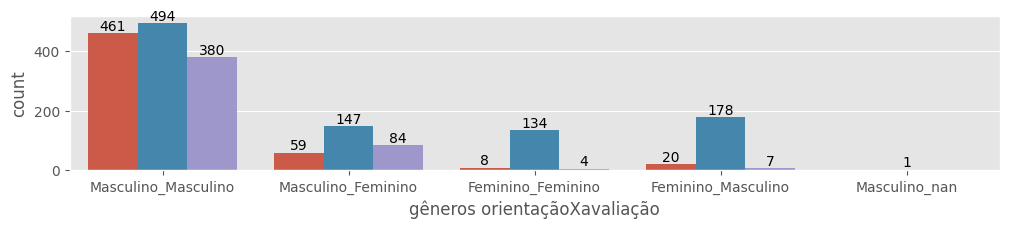

In [122]:
fig, ax = plt.subplots(figsize=(12,2))
c=sns.countplot(data=df[df["pessoa orientadora departamento"].isin(["DSC", "DSI","DTC"])],
                x="gêneros orientaçãoXavaliação",
                hue="pessoa orientadora departamento", stat="count")
c.legend_.remove()
for i, _ in enumerate(df["pessoa orientadora departamento"].unique()):   
    c.bar_label(c.containers[i])

<Axes: xlabel='count', ylabel='aval_genero'>

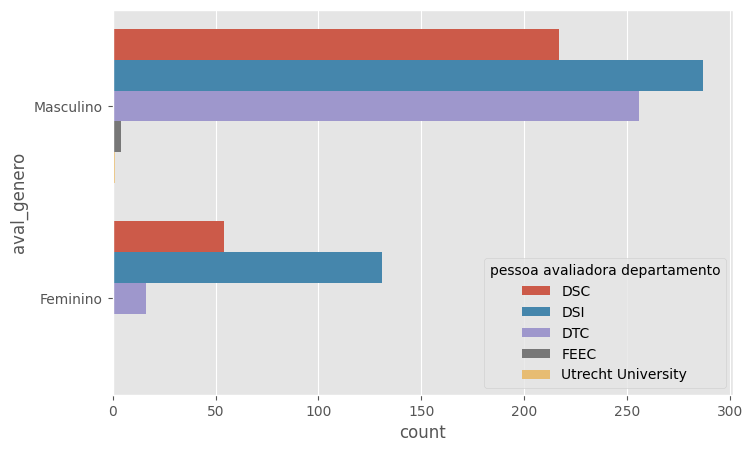

In [76]:
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(data=df, y="aval_genero", hue="pessoa avaliadora departamento", )#order=df["pessoa avaliadora"].value_counts().iloc[0:3].index, width=.5)

<Axes: xlabel='count', ylabel='pessoa avaliadora'>

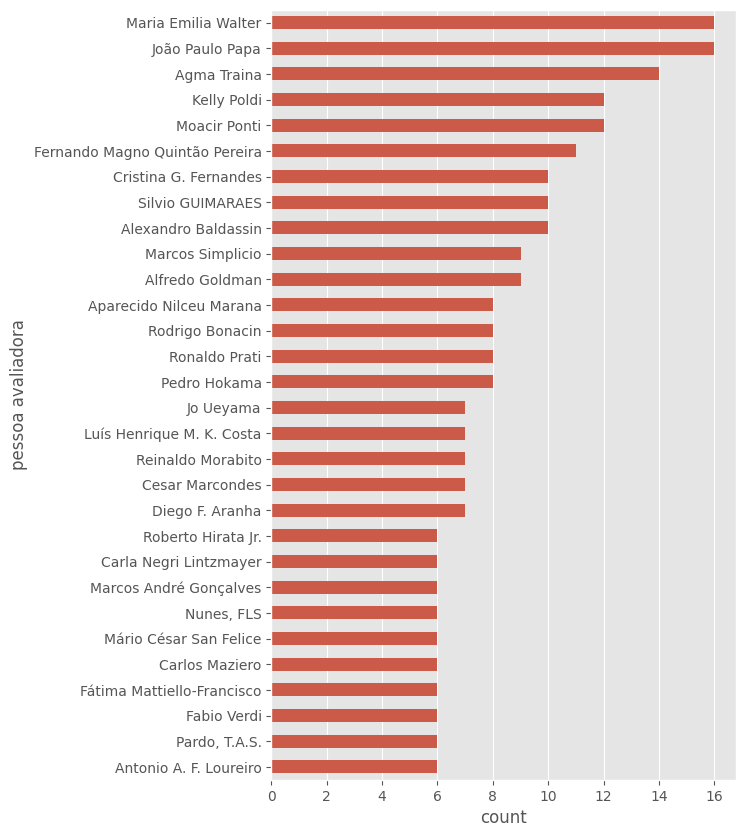

In [59]:
fig, ax = plt.subplots(figsize=(6,10))
sns.countplot(data=df[df["pessoa avaliadora filiacao"]!="Universidade Estadual de Campinas"],
              y="pessoa avaliadora", order=df[df["pessoa avaliadora filiacao"]!="Universidade Estadual de Campinas"]["pessoa avaliadora"].value_counts().iloc[0:30].index, width=.5)